In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the data

In [30]:
data = pd.read_csv('D:/IITM/BSc/DVD/Project/file_zip/application_data.csv')
prev_data= pd.read_csv("D:/IITM/BSc/DVD/Project/file_zip/previous_application.csv")

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [32]:
pd.set_option('display.max_rows', 150)

print(data.isnull().sum())

SK_ID_CURR                           0
TARGET                               0
NAME_CONTRACT_TYPE                   0
CODE_GENDER                          0
FLAG_OWN_CAR                         0
FLAG_OWN_REALTY                      0
CNT_CHILDREN                         0
AMT_INCOME_TOTAL                     0
AMT_CREDIT                           0
AMT_ANNUITY                         12
AMT_GOODS_PRICE                    278
NAME_TYPE_SUITE                   1292
NAME_INCOME_TYPE                     0
NAME_EDUCATION_TYPE                  0
NAME_FAMILY_STATUS                   0
NAME_HOUSING_TYPE                    0
REGION_POPULATION_RELATIVE           0
DAYS_BIRTH                           0
DAYS_EMPLOYED                        0
DAYS_REGISTRATION                    0
DAYS_ID_PUBLISH                      0
OWN_CAR_AGE                     202929
FLAG_MOBIL                           0
FLAG_EMP_PHONE                       0
FLAG_WORK_PHONE                      0
FLAG_CONT_MOBILE         

### Data cleaning

In [33]:
# for all columns (object + numeric)
xna_counts = data.isin(["XAP", "XNA"]).sum()

# show only columns where XNA appears at least once
xna_counts[xna_counts > 0]


CODE_GENDER              4
ORGANIZATION_TYPE    55374
dtype: int64

In [34]:
df = data.replace(["XNA","XAP"], np.nan)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [36]:
# Calculate missing value percentage for df_application_train
missing_percent = (df.isna().sum() / len(df)) * 100

# Display missing percentages sorted from highest to lowest
print("Missing Value Percentages:")
display(missing_percent[missing_percent > 0].sort_values(ascending=False).apply(lambda x: f"{x:.2f}%"))

Missing Value Percentages:


COMMONAREA_AVG                  69.87%
COMMONAREA_MEDI                 69.87%
COMMONAREA_MODE                 69.87%
NONLIVINGAPARTMENTS_MEDI        69.43%
NONLIVINGAPARTMENTS_AVG         69.43%
NONLIVINGAPARTMENTS_MODE        69.43%
FONDKAPREMONT_MODE              68.39%
LIVINGAPARTMENTS_AVG            68.35%
LIVINGAPARTMENTS_MEDI           68.35%
LIVINGAPARTMENTS_MODE           68.35%
FLOORSMIN_MEDI                  67.85%
FLOORSMIN_AVG                   67.85%
FLOORSMIN_MODE                  67.85%
YEARS_BUILD_MODE                66.50%
YEARS_BUILD_MEDI                66.50%
YEARS_BUILD_AVG                 66.50%
OWN_CAR_AGE                     65.99%
LANDAREA_MEDI                   59.38%
LANDAREA_AVG                    59.38%
LANDAREA_MODE                   59.38%
BASEMENTAREA_MODE               58.52%
BASEMENTAREA_MEDI               58.52%
BASEMENTAREA_AVG                58.52%
EXT_SOURCE_1                    56.38%
NONLIVINGAREA_MODE              55.18%
NONLIVINGAREA_MEDI       

In [37]:
columns_to_drop = missing_percent[missing_percent > 47].index

# Drop columns
df.drop(columns=columns_to_drop, inplace=True)

# Print removed columns
print(f"Dropped {len(columns_to_drop)} columns with more than 47% missing values.")
print("Dropped columns:", list(columns_to_drop))

Dropped 49 columns with more than 47% missing values.
Dropped columns: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSET

In [38]:
print(df.shape)
print(data.shape)

(307511, 73)
(307511, 122)


In [39]:
prev_data.shape

(1670214, 37)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307507 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

### Imputing missing values

In [41]:
# 1A. Numeric columns – median imputation
num_cols = df.select_dtypes(include=["number"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 1B. Categorical columns – "Unknown" category
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("categorical columns:", list(cat_cols))
print("numeric columns:", list(num_cols))

categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']
numeric columns: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL

In [42]:
df.isna().sum()

SK_ID_CURR                     0
TARGET                         0
NAME_CONTRACT_TYPE             0
CODE_GENDER                    0
FLAG_OWN_CAR                   0
FLAG_OWN_REALTY                0
CNT_CHILDREN                   0
AMT_INCOME_TOTAL               0
AMT_CREDIT                     0
AMT_ANNUITY                    0
AMT_GOODS_PRICE                0
NAME_TYPE_SUITE                0
NAME_INCOME_TYPE               0
NAME_EDUCATION_TYPE            0
NAME_FAMILY_STATUS             0
NAME_HOUSING_TYPE              0
REGION_POPULATION_RELATIVE     0
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_REGISTRATION              0
DAYS_ID_PUBLISH                0
FLAG_MOBIL                     0
FLAG_EMP_PHONE                 0
FLAG_WORK_PHONE                0
FLAG_CONT_MOBILE               0
FLAG_PHONE                     0
FLAG_EMAIL                     0
OCCUPATION_TYPE                0
CNT_FAM_MEMBERS                0
REGION_RATING_CLIENT           0
REGION_RAT

### Univariate analysis by default %

In [43]:
# default rate by category

def default_rate_by_cat(col):
    return (df.groupby(col)["TARGET"]
              .mean()
              .sort_values(ascending=False))


In [44]:
default_rate_by_cat("NAME_INCOME_TYPE")
# default_rate_by_cat("NAME_EDUCATION_TYPE")
# default_rate_by_cat("OCCUPATION_TYPE")

NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64

### Previous application data cleaning

In [45]:
prev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [46]:
# counts of XAP or XNA in each column of prev_df
pre_xna_counts = prev_data.isin(["XAP", "XNA"]).sum()

# show only columns where they appear at least once
pre_xna_counts[pre_xna_counts > 0]


NAME_CONTRACT_TYPE            346
NAME_CASH_LOAN_PURPOSE    1600579
NAME_PAYMENT_TYPE          627384
CODE_REJECT_REASON        1358337
NAME_CLIENT_TYPE             1941
NAME_GOODS_CATEGORY        950809
NAME_PORTFOLIO             372230
NAME_PRODUCT_TYPE         1063666
NAME_SELLER_INDUSTRY       855720
NAME_YIELD_GROUP           517215
dtype: int64

In [47]:
prev_df = prev_data.replace(["XNA","XAP"], np.nan)


In [48]:
prev_df.isna().sum()


SK_ID_PREV                           0
SK_ID_CURR                           0
NAME_CONTRACT_TYPE                 346
AMT_ANNUITY                     372235
AMT_APPLICATION                      0
AMT_CREDIT                           1
AMT_DOWN_PAYMENT                895844
AMT_GOODS_PRICE                 385515
WEEKDAY_APPR_PROCESS_START           0
HOUR_APPR_PROCESS_START              0
FLAG_LAST_APPL_PER_CONTRACT          0
NFLAG_LAST_APPL_IN_DAY               0
RATE_DOWN_PAYMENT               895844
RATE_INTEREST_PRIMARY          1664263
RATE_INTEREST_PRIVILEGED       1664263
NAME_CASH_LOAN_PURPOSE         1600579
NAME_CONTRACT_STATUS                 0
DAYS_DECISION                        0
NAME_PAYMENT_TYPE               627384
CODE_REJECT_REASON             1358337
NAME_TYPE_SUITE                 820405
NAME_CLIENT_TYPE                  1941
NAME_GOODS_CATEGORY             950809
NAME_PORTFOLIO                  372230
NAME_PRODUCT_TYPE              1063666
CHANNEL_TYPE             

In [49]:
# Calculate missing value percentage for df_application_train
pre_missing_percent = (prev_df.isna().sum() / len(prev_df)) * 100

# Display missing percentages sorted from highest to lowest
print("Missing Value Percentages:")
display(pre_missing_percent[pre_missing_percent > 0].sort_values(ascending=False).apply(lambda x: f"{x:.2f}%"))

Missing Value Percentages:


RATE_INTEREST_PRIMARY        99.64%
RATE_INTEREST_PRIVILEGED     99.64%
NAME_CASH_LOAN_PURPOSE       95.83%
CODE_REJECT_REASON           81.33%
NAME_PRODUCT_TYPE            63.68%
NAME_GOODS_CATEGORY          56.93%
AMT_DOWN_PAYMENT             53.64%
RATE_DOWN_PAYMENT            53.64%
NAME_SELLER_INDUSTRY         51.23%
NAME_TYPE_SUITE              49.12%
DAYS_TERMINATION             40.30%
DAYS_LAST_DUE                40.30%
DAYS_LAST_DUE_1ST_VERSION    40.30%
DAYS_FIRST_DUE               40.30%
DAYS_FIRST_DRAWING           40.30%
NFLAG_INSURED_ON_APPROVAL    40.30%
NAME_PAYMENT_TYPE            37.56%
NAME_YIELD_GROUP             30.97%
AMT_GOODS_PRICE              23.08%
AMT_ANNUITY                  22.29%
NAME_PORTFOLIO               22.29%
CNT_PAYMENT                  22.29%
NAME_CLIENT_TYPE              0.12%
PRODUCT_COMBINATION           0.02%
NAME_CONTRACT_TYPE            0.02%
AMT_CREDIT                    0.00%
dtype: object

In [50]:
pre_columns_to_drop = pre_missing_percent[pre_missing_percent > 85].index

# Drop columns
prev_df.drop(columns=pre_columns_to_drop, inplace=True)

# Print removed columns
print(f"Dropped {len(pre_columns_to_drop)} columns with more than 85% missing values.")
print("Dropped columns:", list(pre_columns_to_drop))

Dropped 3 columns with more than 85% missing values.
Dropped columns: ['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE']


In [51]:
prev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 34 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1669868 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [52]:
# safety copy
app = df.copy()
prev = prev_df.copy()

### Merging both application and previous application

In [53]:
# 1. Helper flags (vectorized, very fast)
prev["is_refused_or_canceled"] = prev["NAME_CONTRACT_STATUS"].isin(["Refused", "Canceled"]).astype(int)
prev["is_unused_offer"]       = (prev["NAME_CONTRACT_STATUS"] == "Unused offer").astype(int)
prev["is_approved"]           = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)

prev["is_revolving"]          = (prev["NAME_CONTRACT_TYPE"] == "Revolving loans").astype(int)
prev["is_cash"]               = (prev["NAME_CONTRACT_TYPE"] == "Cash loans").astype(int)
prev["is_consumer"]           = (prev["NAME_CONTRACT_TYPE"] == "Consumer loans").astype(int)

# 2. Groupby with simple aggregations
agg_prev = prev.groupby("SK_ID_CURR").agg(
    prev_application_count              = ("SK_ID_PREV", "nunique"),
    loan_rejected_or_cancelled_count    = ("is_refused_or_canceled", "sum"),
    loan_unused_offer_count             = ("is_unused_offer", "sum"),
    loan_approved_count                 = ("is_approved", "sum"),
    revolving_loans_count               = ("is_revolving", "sum"),
    cash_loans_count                    = ("is_cash", "sum"),
    consumer_loans_count                = ("is_consumer", "sum"),
)
agg_prev.head()

,prev_application_count,loan_rejected_or_cancelled_count,loan_unused_offer_count,loan_approved_count,revolving_loans_count,cash_loans_count,consumer_loans_count
SK_ID_CURR,,,,,,,
100001,1,0,0,1,0,0,1
100002,1,0,0,1,0,0,1
100003,3,0,0,3,0,1,2
100004,1,0,0,1,0,0,1
100005,2,1,0,1,0,1,1


In [54]:
# Helper flags (vectorized)
prev["is_approved"]      = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
prev["is_reject_HC"]     = (prev["CODE_REJECT_REASON"] == "HC").astype(int)
prev["is_reject_VERIF"]  = (prev["CODE_REJECT_REASON"] == "VERIF").astype(int)
prev["is_reject_LIMIT"]  = (prev["CODE_REJECT_REASON"] == "LIMIT").astype(int)
prev["is_reject_CLIENT"]  = (prev["CODE_REJECT_REASON"] == "CLIENT").astype(int)
prev["is_reject_SCO_SCOFR"]  = (prev["CODE_REJECT_REASON"].isin(["SCO","SCOFR"])).astype(int)
prev["is_reject_SYSTEM"]  = (prev["CODE_REJECT_REASON"] == "SYSTEM").astype(int)

# Groupby with fast aggregations
extra_agg = prev.groupby("SK_ID_CURR").agg(
    # approval ratio = share of previous apps that were approved
    prev_approved_ratio     = ("is_approved", "mean"),

    # credit / annuity stats
    prev_mean_amt_credit    = ("AMT_CREDIT", "mean"),
    prev_max_amt_credit     = ("AMT_CREDIT", "max"),
    prev_mean_amt_annuity   = ("AMT_ANNUITY", "mean"),

    # reject-reason counts
    prev_hc_reject_count    = ("is_reject_HC", "sum"),
    prev_verif_reject_count = ("is_reject_VERIF", "sum"),
    prev_limit_reject_count = ("is_reject_LIMIT", "sum"),
    prev_client_reject_count = ("is_reject_CLIENT", "sum"),
    prev_sco_scofr_reject_count = ("is_reject_SCO_SCOFR", "sum"),
    prev_system_reject_count = ("is_reject_SYSTEM", "sum"),

    # recency (if you have DAYS_DECISION)
    prev_min_days_decision  = ("DAYS_DECISION", "min"),
    prev_max_days_decision  = ("DAYS_DECISION", "max"),
)


In [55]:
prev_features = agg_prev.join(extra_agg, how="left")

In [56]:
# merge on SK_ID_CURR, keeping all customers from application data
app_full = df.merge(
    prev_features,
    on="SK_ID_CURR",
    how="left"
)

app_full.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,prev_max_amt_credit,prev_mean_amt_annuity,prev_hc_reject_count,prev_verif_reject_count,prev_limit_reject_count,prev_client_reject_count,prev_sco_scofr_reject_count,prev_system_reject_count,prev_min_days_decision,prev_max_days_decision
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,179055.0,9251.775,0.0,0.0,0.0,0.0,0.0,0.0,-606.0,-606.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,1035882.0,56553.990,0.0,0.0,0.0,0.0,0.0,0.0,-2341.0,-746.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,20106.0,5357.250,0.0,0.0,0.0,0.0,0.0,0.0,-815.0,-815.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,906615.0,23651.175,0.0,0.0,1.0,0.0,0.0,0.0,-617.0,-181.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,284400.0,12278.805,0.0,0.0,0.0,0.0,0.0,0.0,-2357.0,-374.0


In [57]:
# total critical rejections per customer
app_full["critical_reject_count"] = (
    app_full["prev_hc_reject_count"]
    + app_full["prev_sco_scofr_reject_count"]
    + app_full["prev_limit_reject_count"]
)


### Outlier detection and handling

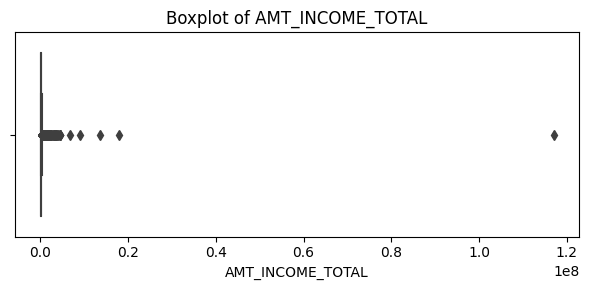

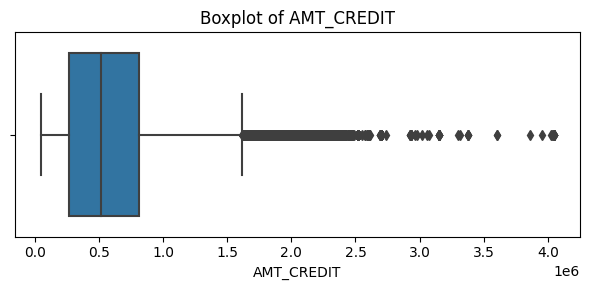

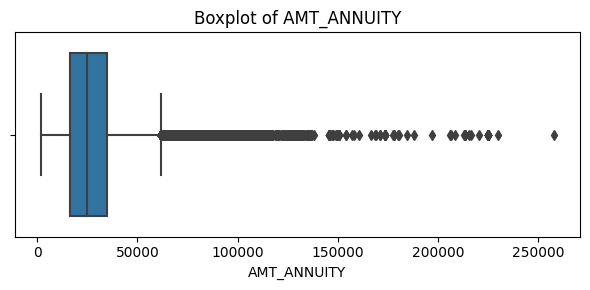

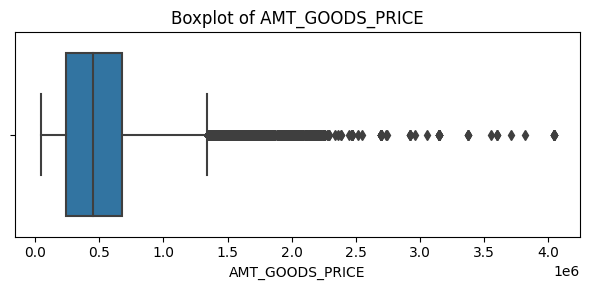

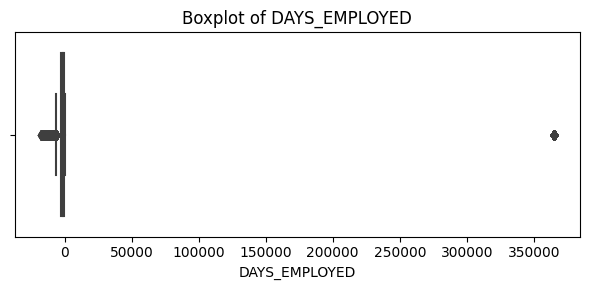

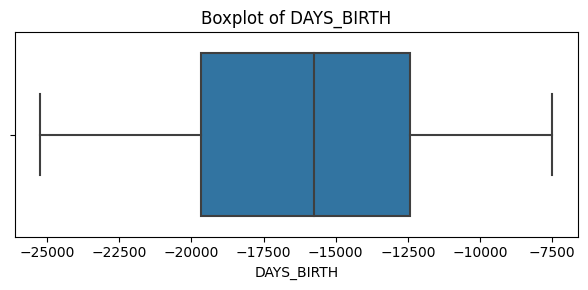

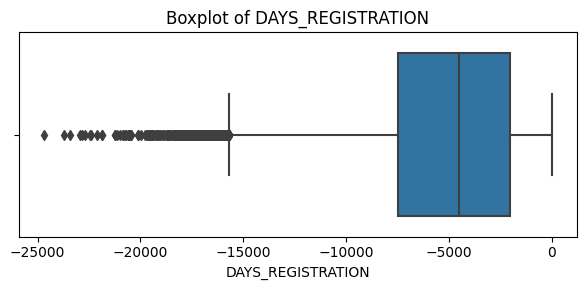

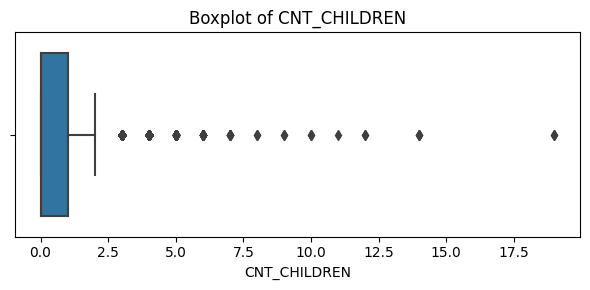

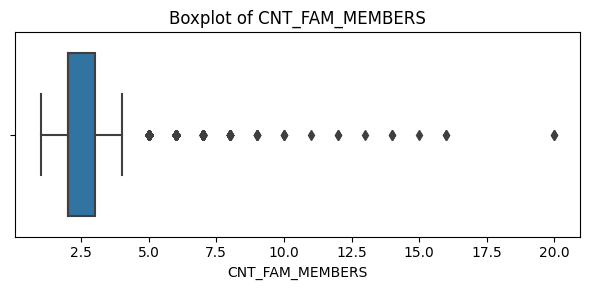

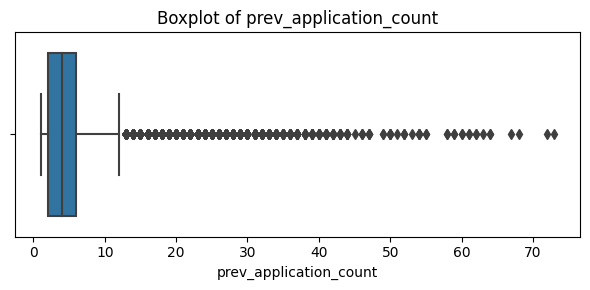

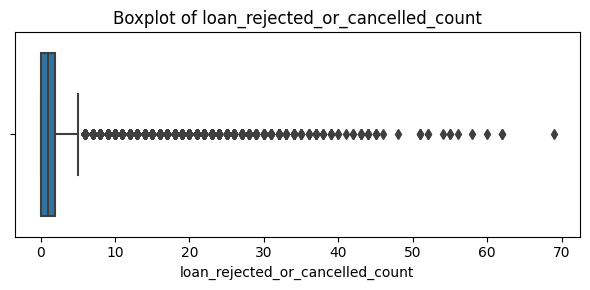

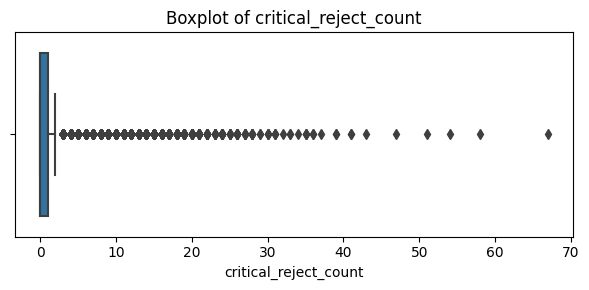

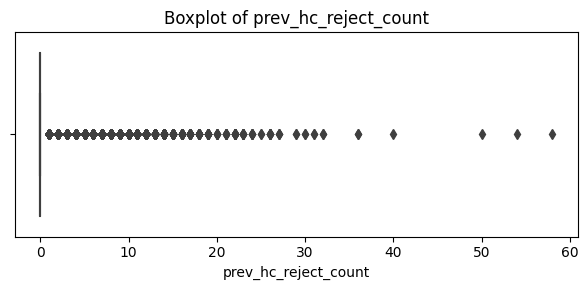

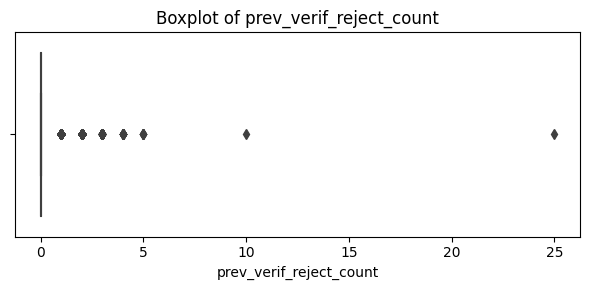

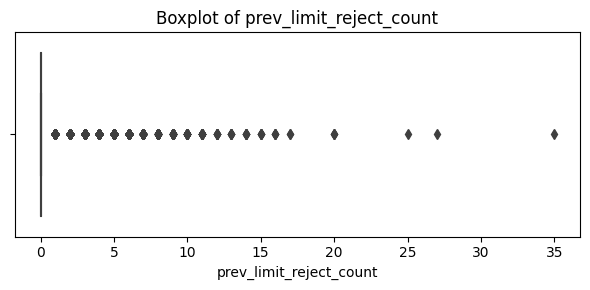

In [58]:
num_cols_for_outliers = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_EMPLOYED", "DAYS_BIRTH", "DAYS_REGISTRATION",
    "CNT_CHILDREN","CNT_FAM_MEMBERS",
    "prev_application_count", "loan_rejected_or_cancelled_count", "critical_reject_count","prev_hc_reject_count"
    , "prev_verif_reject_count", "prev_limit_reject_count"
]

for col in num_cols_for_outliers:
    if col in app_full.columns:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x=app_full[col])
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()
        plt.show()


Treating them in 3 groups:

- Amounts: `AMT_GOODS_PRICE`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_INCOME_TOTAL`, `CNT_CHILDREN`, `CNT_FAM_MEMBERS` - capped at upper value
- Time: `DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION` - made specific changes
- Behaviour counts: `prev_application_count`, `critical_reject_count`, `loan_rejected_or_cancelled_count` - kept as is



In [59]:
import numpy as np

def cap_outliers_iqr(df, col, factor=1.5):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    df[col] = df[col].clip(lower, upper)
    return df

amt_cols = ["AMT_GOODS_PRICE", "AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL"]

for col in amt_cols:
    if col in app_full.columns:
        app_full = cap_outliers_iqr(app_full, col, factor=1.5)


In [60]:
not_employed_flag = (app_full["DAYS_EMPLOYED"] == 365243)
app_full.loc[not_employed_flag, "DAYS_EMPLOYED"] = np.nan  # or set a flag column
app_full["NOT_EMPLOYED_FLAG"] = not_employed_flag.astype(int)

In [61]:
app_full["AGE_YEARS"] = (-app_full["DAYS_BIRTH"] / 365).round(1)
app_full["YEARS_REGISTRATION"] = (-app_full["DAYS_REGISTRATION"] / 365)
app_full = cap_outliers_iqr(app_full, "YEARS_REGISTRATION", factor=1.5)


In [62]:
# children cap
app_full["CNT_CHILDREN"] = app_full["CNT_CHILDREN"].clip(upper=5)

# family members cap
app_full["CNT_FAM_MEMBERS"] = app_full["CNT_FAM_MEMBERS"].clip(upper=7)


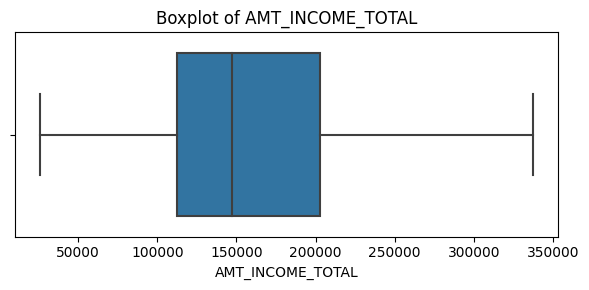

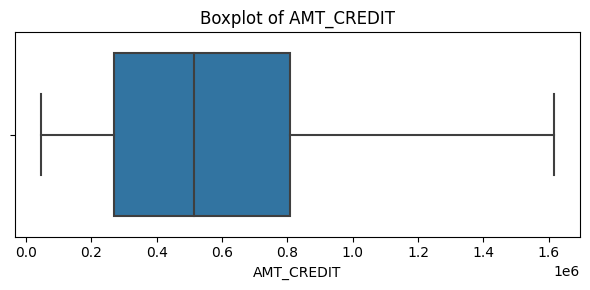

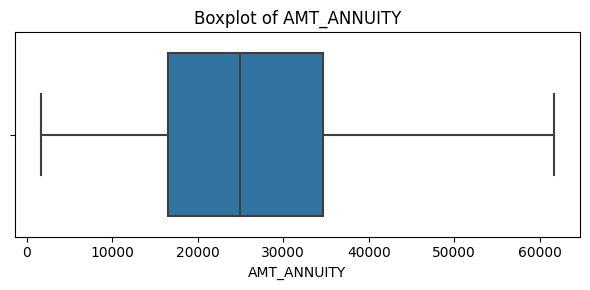

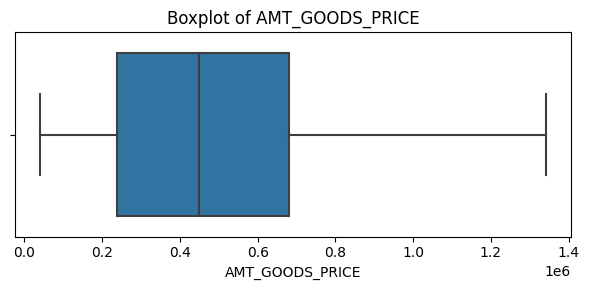

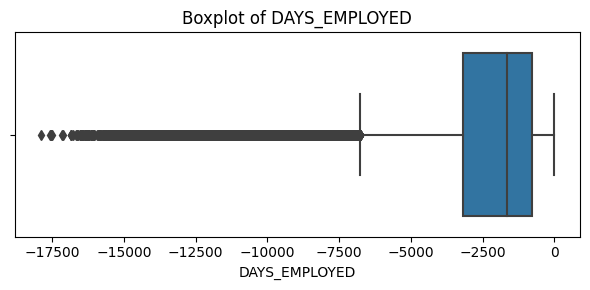

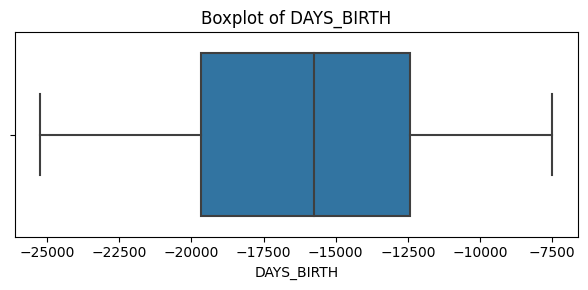

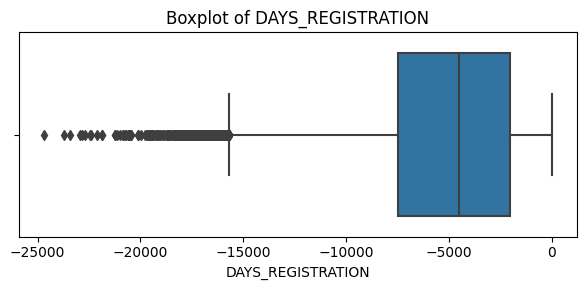

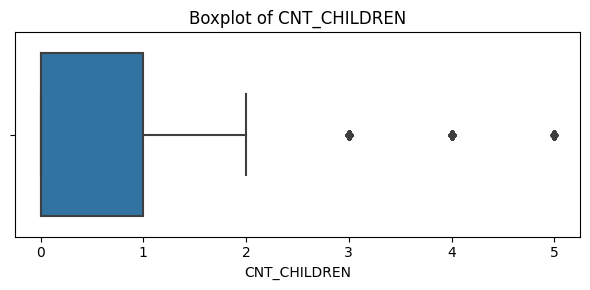

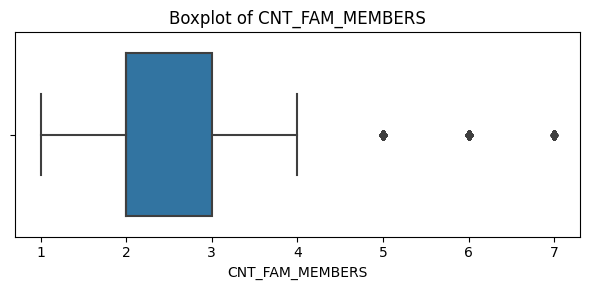

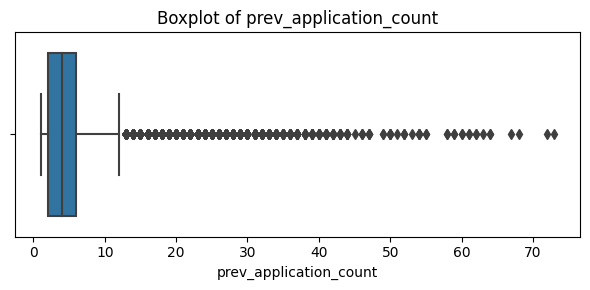

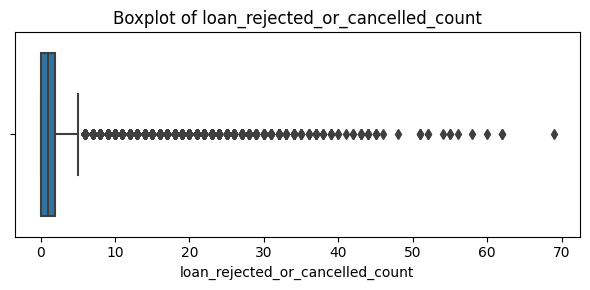

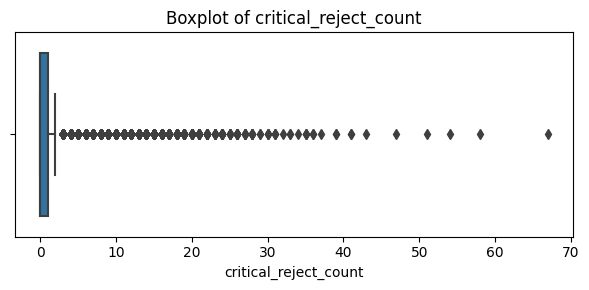

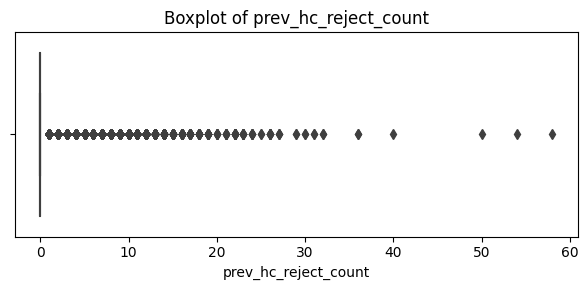

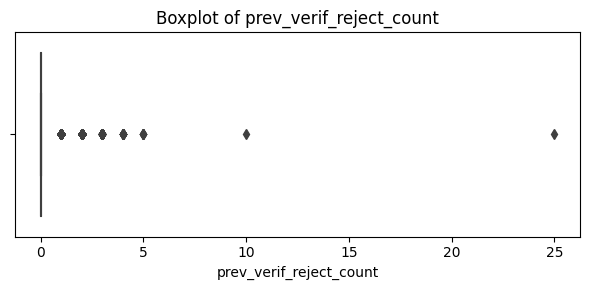

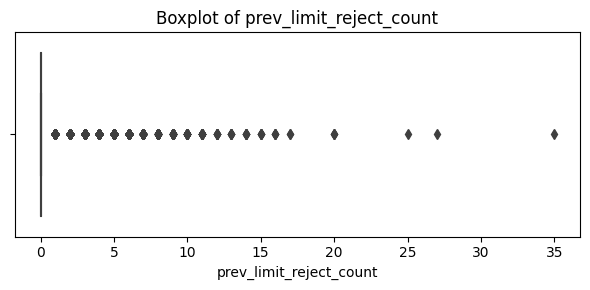

In [63]:
for col in num_cols_for_outliers:
    if col in app_full.columns:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x=app_full[col])
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()
        plt.show()

### External Source Weighted sum

In [64]:
ext_cols = ["EXT_SOURCE_2", "EXT_SOURCE_3"]

# compute absolute correlations with TARGET
corrs = app_full[ext_cols + ["TARGET"]].corr()["TARGET"][ext_cols].abs()
print(corrs)

# normalize to sum to 1
weights = corrs / corrs.sum()
print(weights.to_dict())

w2 = weights["EXT_SOURCE_2"]
w3 = weights["EXT_SOURCE_3"]

app_full["EXT_SCORE_WEIGHTED"] = (
    w2 * app_full["EXT_SOURCE_2"].fillna(app_full["EXT_SOURCE_2"].median()) +
    w3 * app_full["EXT_SOURCE_3"].fillna(app_full["EXT_SOURCE_3"].median())
)

EXT_SOURCE_2    0.160295
EXT_SOURCE_3    0.155892
Name: TARGET, dtype: float64
{'EXT_SOURCE_2': 0.5069627710823771, 'EXT_SOURCE_3': 0.49303722891762297}


### Correlation with Target

In [65]:
# if your DataFrame is already loaded as df, set the target column name:
target_col = "TARGET"

# keep only numeric columns (correlation works on numbers)
numeric_df = app_full.select_dtypes(include="number")

# correlation of all numeric columns with the target
corr_with_target = numeric_df.corr()[target_col].sort_values(ascending=False)

print(corr_with_target)


TARGET                              1.000000
DAYS_BIRTH                          0.078239
DAYS_EMPLOYED                       0.074958
critical_reject_count               0.064894
REGION_RATING_CLIENT_W_CITY         0.060893
REGION_RATING_CLIENT                0.058899
DAYS_LAST_PHONE_CHANGE              0.055218
prev_min_days_decision              0.053434
loan_rejected_or_cancelled_count    0.051971
DAYS_ID_PUBLISH                     0.051457
REG_CITY_NOT_WORK_CITY              0.050994
prev_hc_reject_count                0.047067
FLAG_EMP_PHONE                      0.045982
revolving_loans_count               0.045602
REG_CITY_NOT_LIVE_CITY              0.044395
FLAG_DOCUMENT_3                     0.044346
DAYS_REGISTRATION                   0.041975
prev_sco_scofr_reject_count         0.040763
prev_limit_reject_count             0.040503
LIVE_CITY_NOT_WORK_CITY             0.032518
DEF_30_CNT_SOCIAL_CIRCLE            0.032394
DEF_60_CNT_SOCIAL_CIRCLE            0.031401
FLAG_WORK_

In [66]:
# drop TARGET itself
corr_no_target = corr_with_target.drop(labels=["TARGET"])

# sort by absolute correlation
corr_abs = corr_no_target.abs().sort_values(ascending=False)

N = 21
top_features = corr_abs.head(N).index
print(top_features)


Index(['EXT_SCORE_WEIGHTED', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'AGE_YEARS', 'DAYS_EMPLOYED', 'critical_reject_count',
       'prev_approved_ratio', 'REGION_RATING_CLIENT_W_CITY',
       'REGION_RATING_CLIENT', 'DAYS_LAST_PHONE_CHANGE',
       'prev_min_days_decision', 'loan_rejected_or_cancelled_count',
       'DAYS_ID_PUBLISH', 'REG_CITY_NOT_WORK_CITY', 'prev_hc_reject_count',
       'NOT_EMPLOYED_FLAG', 'FLAG_EMP_PHONE', 'revolving_loans_count',
       'REG_CITY_NOT_LIVE_CITY', 'FLAG_DOCUMENT_3'],
      dtype='object')


In [67]:
corr_df = app_full[top_features.tolist() + [target_col]].corr()

In [68]:
corr_df.to_csv("correlation_matrix.csv")

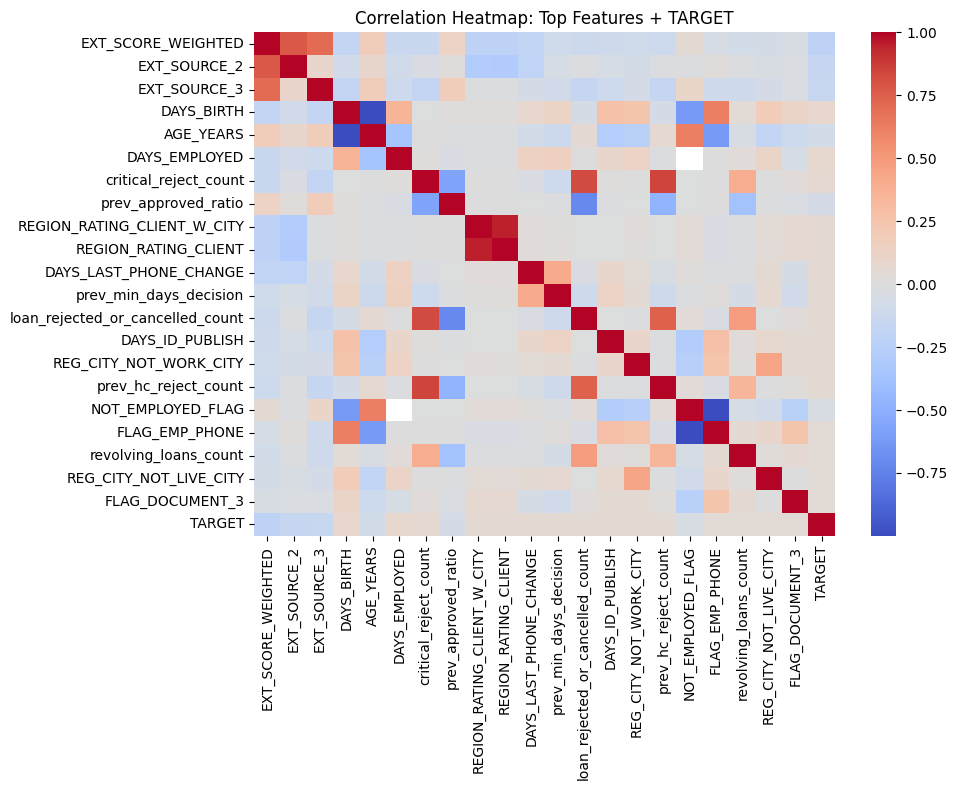

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    app_full[top_features.tolist() + [target_col]].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap: Top Features + TARGET")
plt.tight_layout()
plt.show()


# Analysis

### 1. Default rate vs binned drivers

In [70]:
def plot_default_rate_by_bin(a_df, col, bins, labels=None, figsize=(6,4)):
    tmp = a_df.copy()
    tmp[col + "_bin"] = pd.cut(tmp[col], bins=bins, labels=labels, include_lowest=True)
    grp = (tmp
           .groupby(col + "_bin", observed=True)["TARGET"]
           .mean()
           .reset_index())
    grp["default_rate_pct"] = grp["TARGET"] * 100
    
    plt.figure(figsize=figsize)
    sns.barplot(data=grp, x=col + "_bin", y="default_rate_pct", color="steelblue")
    plt.xticks(rotation=45)
    plt.ylabel("Default rate (%)")
    plt.xlabel(col + " (binned)")
    plt.title(f"Default rate by {col} bin")
    plt.tight_layout()
    plt.show()


##### a) Age – DAYS_BIRTH bands

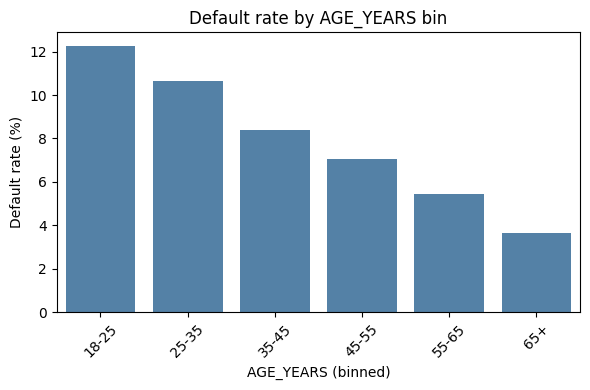

In [71]:
age_bins   = [18, 25, 35, 45, 55, 65, 80]
age_labels = ["18-25", "25-35", "35-45", "45-55", "55-65", "65+"]

plot_default_rate_by_bin(app_full, "AGE_YEARS", age_bins, age_labels)


##### b) Region rating categories

In [ ]:
overall_default_pct = app_full["TARGET"].mean() * 100
print(overall_default_pct)

8.072881945686495


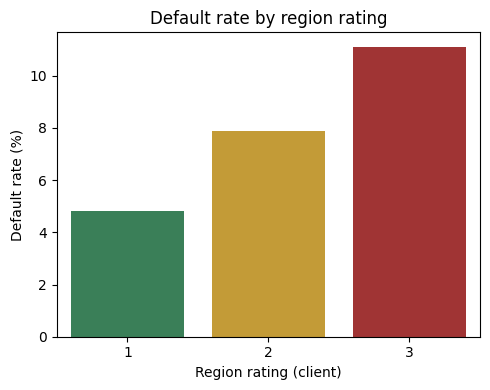

In [ ]:
reg_grp = (app_full
           .groupby("REGION_RATING_CLIENT")["TARGET"]
           .mean()
           .reset_index())
reg_grp["default_rate_pct"] = reg_grp["TARGET"] * 100

palette = {
    1: "seagreen",   # low risk
    2: "goldenrod",  # medium
    3: "firebrick",  # high
}

plt.figure(figsize=(5,4))
sns.barplot(data=reg_grp, x="REGION_RATING_CLIENT", y="default_rate_pct", palette=palette)
plt.ylabel("Default rate (%)")
plt.xlabel("Region rating (client)")
plt.title("Default rate by region rating")
plt.tight_layout()
plt.show()


##### c) prev_min_days_decision (recency of earliest previous app)

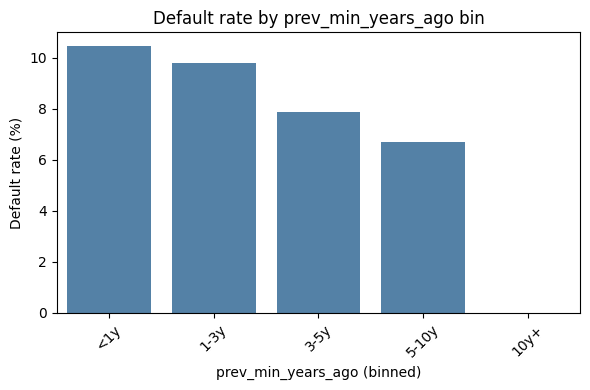

In [ ]:
# days are usually negative; convert to years ago
app_full["prev_min_years_ago"] = (-app_full["prev_min_days_decision"] / 365)

dec_bins   = [0, 1, 3, 5, 10, 30]
dec_labels = ["<1y", "1-3y", "3-5y", "5-10y", "10y+"]

plot_default_rate_by_bin(app_full, "prev_min_years_ago", dec_bins, dec_labels)


##### d) Count features

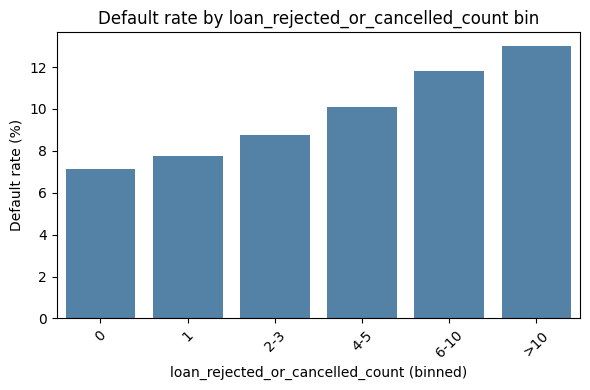

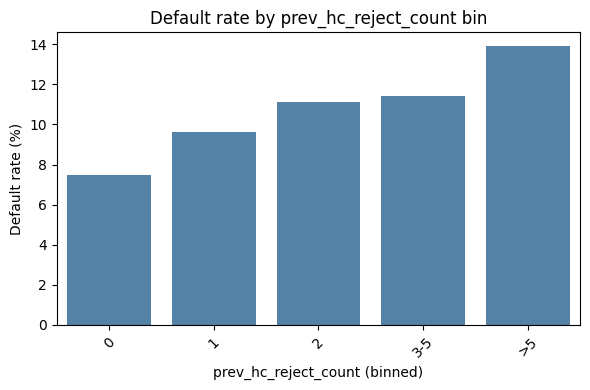

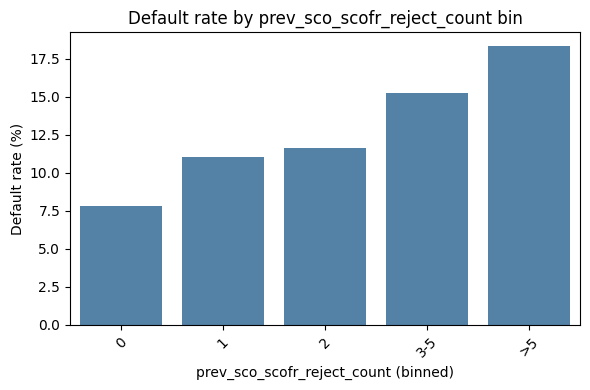

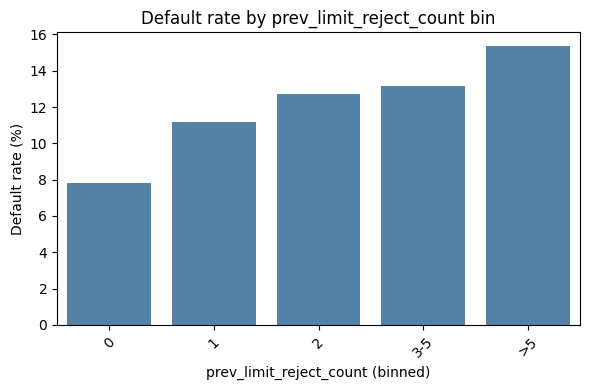

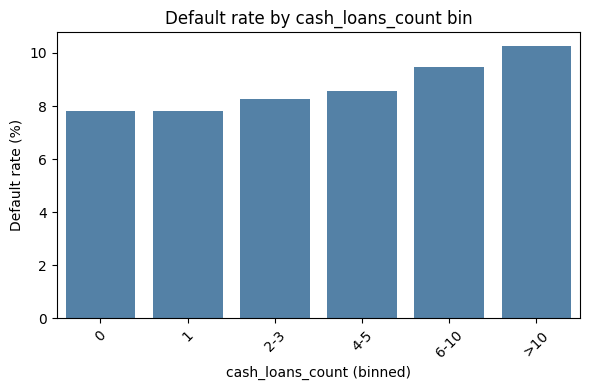

In [ ]:
# loan_rejected_or_cancelled_count
rej_bins   = [-0.1, 0, 1, 3, 5, 10, 100]
rej_labels = ["0", "1", "2-3", "4-5", "6-10", ">10"]
plot_default_rate_by_bin(app_full, "loan_rejected_or_cancelled_count", rej_bins, rej_labels)

# prev_hc_reject_count
hc_bins   = [-0.1, 0, 1, 2, 5, 100]
hc_labels = ["0", "1", "2", "3-5", ">5"]
plot_default_rate_by_bin(app_full, "prev_hc_reject_count", hc_bins, hc_labels)

plot_default_rate_by_bin(app_full, "prev_sco_scofr_reject_count", hc_bins, hc_labels)

plot_default_rate_by_bin(app_full, "prev_limit_reject_count", hc_bins, hc_labels)


# cash_loans_count
cash_bins   = [-0.1, 0, 1, 3, 5, 10, 100]
cash_labels = ["0", "1", "2-3", "4-5", "6-10", ">10"]
plot_default_rate_by_bin(app_full, "cash_loans_count", cash_bins, cash_labels)


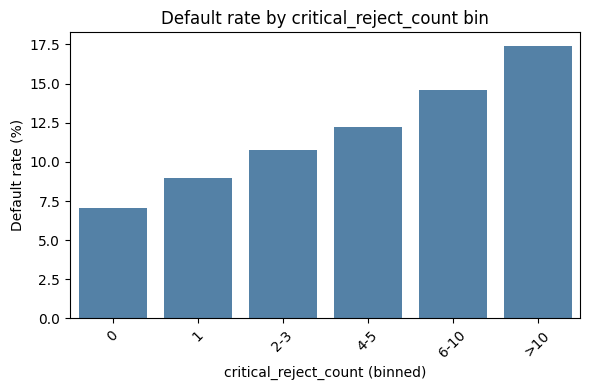

In [ ]:
crit_bins   = [-0.1, 0, 1, 3, 5, 10, 100]
crit_labels = ["0", "1", "2-3", "4-5", "6-10", ">10"]

plot_default_rate_by_bin(
    app_full,
    col="critical_reject_count",
    bins=crit_bins,
    labels=crit_labels
)


### 2. Segment plots: income × behaviour

##### a) Income band × loan_rejected_or_cancelled_count (heatmap)

Max income: 337500.0
0.0 69.0


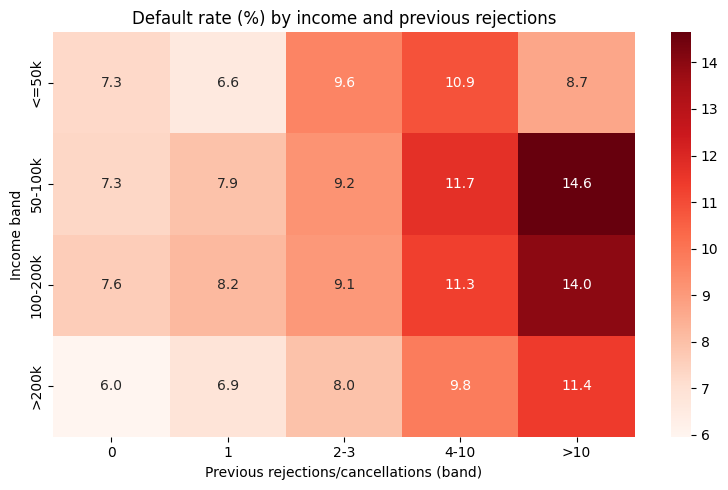

In [138]:
# income bands
max_income = app_full["AMT_INCOME_TOTAL"].max()
print("Max income:", max_income)

# ensure last edge is > second last edge
upper_edge = max(max_income, 1_000_000) + 1  # force strictly larger

income_bins   = [0, 50_000, 100_000, 200_000, upper_edge]
income_labels = ["<=50k", "50-100k", "100-200k", ">200k"]

app_full["INCOME_BAND"] = pd.cut(
    app_full["AMT_INCOME_TOTAL"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

# make sure the column is numeric
app_full["loan_rejected_or_cancelled_count"] = pd.to_numeric(
    app_full["loan_rejected_or_cancelled_count"], errors="coerce"
)

# check min/max
print(app_full["loan_rejected_or_cancelled_count"].min(),
      app_full["loan_rejected_or_cancelled_count"].max())

# redefine bins with ints only (and strictly increasing)
rej_bins   = [-1, 0, 1, 3, 10, app_full["loan_rejected_or_cancelled_count"].max() + 1]
rej_labels = ["0", "1", "2-3", "4-10", ">10"]

app_full["REJ_BAND"] = pd.cut(
    app_full["loan_rejected_or_cancelled_count"],
    bins=rej_bins,
    labels=rej_labels,
    include_lowest=True
)

# pivot default rate
pivot = (app_full
         .groupby(["INCOME_BAND", "REJ_BAND"], observed=True)["TARGET"]
         .mean()
         .unstack("REJ_BAND"))

plt.figure(figsize=(8,5))
sns.heatmap(pivot * 100, annot=True, fmt=".1f", cmap="Reds")
plt.xlabel("Previous rejections/cancellations (band)")
plt.ylabel("Income band")
plt.title("Default rate (%) by income and previous rejections")
plt.tight_layout()
plt.show()


##### b) Income band × prev_approved_ratio

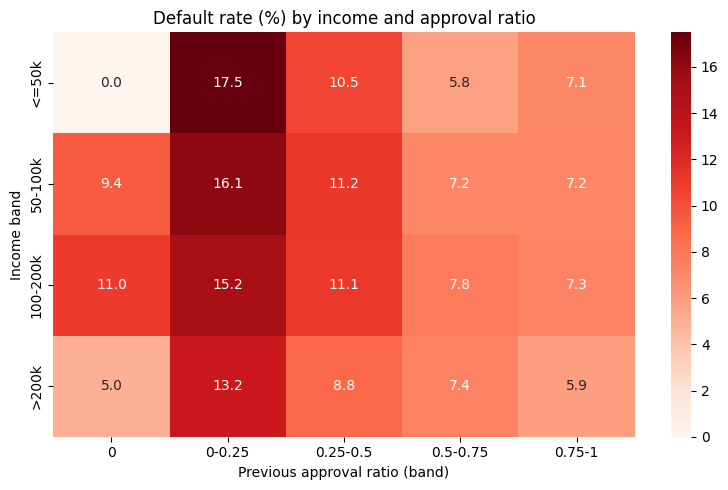

In [139]:
# approval ratio bands
app_full["APPROVED_RATIO_BAND"] = pd.cut(
    app_full["prev_approved_ratio"],
    bins=[-0.01, 0, 0.25, 0.5, 0.75, 1.0],
    labels=["0", "0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1"],
    include_lowest=True
)

pivot2 = (app_full
          .groupby(["INCOME_BAND", "APPROVED_RATIO_BAND"], observed=True)["TARGET"]
          .mean()
          .unstack("APPROVED_RATIO_BAND"))

plt.figure(figsize=(8,5))
sns.heatmap(pivot2 * 100, annot=True, fmt=".1f", cmap="Reds")
plt.xlabel("Previous approval ratio (band)")
plt.ylabel("Income band")
plt.title("Default rate (%) by income and approval ratio")
plt.tight_layout()
plt.show()


# Questions

###  A)  Customer Profile Questions

##### 1. How does the default rate vary with age?

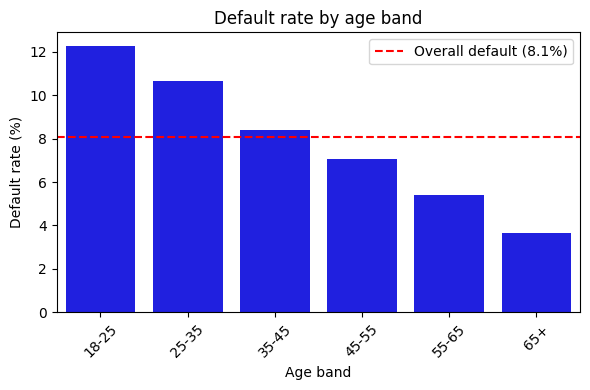

In [247]:
# overall default rate in percent (from full dataset)
overall_default_pct = app_full["TARGET"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=age_grp,
    x="AGE_BAND",
    y="default_rate_pct",
    color="blue",
    ax=ax
)

ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Age band")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Default rate by age band")

# average reference line
ax.axhline(
    y=overall_default_pct,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall default ({overall_default_pct:.1f}%)"
)

ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [240]:
age_grp1 = (
    app_full
    .groupby("AGE_BAND", observed=True)["TARGET"]
    .agg(
        default_rate="mean",    # mean of TARGET
        n_customers="count"     # number of records in each AGE_BAND
    )
    .reset_index()
)
age_grp1


,AGE_BAND,default_rate,n_customers
0,18-25,0.122725,12361
1,25-35,0.106480,72483
2,35-45,0.084138,84088
3,45-55,0.070443,70270
4,55-65,0.054228,60449
5,65+,0.036514,7860


##### 2.	Do customers with lower income have higher default rates?

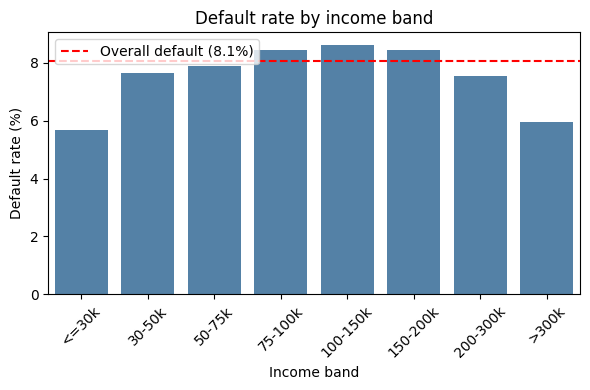

In [249]:
# overall default rate in percent (on full data)
overall_default_pct = app_full["TARGET"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=inc_grp,
    x="INCOME_BAND",
    y="default_rate_pct",
    color="steelblue",
    ax=ax
)

ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Income band")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Default rate by income band")

# reference line at overall default %
ax.axhline(
    y=overall_default_pct,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall default ({overall_default_pct:.1f}%)"
)

ax.legend(loc="best")
plt.tight_layout()
plt.show()


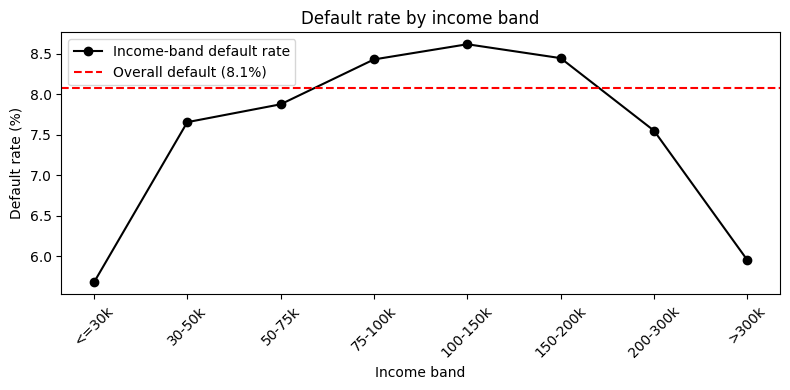

In [250]:
# overall default rate (%) from full data
overall_default_pct = app_full["TARGET"].mean() * 100

plt.figure(figsize=(8, 4))
ax = plt.gca()

ax.plot(
    inc_grp["INCOME_BAND"],
    inc_grp["default_rate_pct"],
    color="black",
    marker="o",
    label="Income-band default rate"
)

# reference line
ax.axhline(
    y=overall_default_pct,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall default ({overall_default_pct:.1f}%)"
)

ax.set_xlabel("Income band")
ax.set_ylabel("Default rate (%)")
plt.title("Default rate by income band")
plt.xticks(rotation=45)
ax.legend(loc="best")

plt.tight_layout()
plt.show()


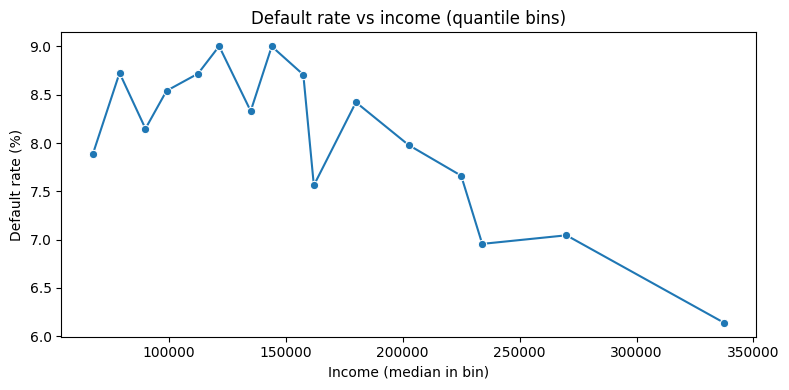

In [143]:
# quantile-based bins (e.g., 20 equal-sized groups)
app_full["INCOME_QBIN"] = pd.qcut(
    app_full["AMT_INCOME_TOTAL"],
    q=20,
    duplicates="drop"
)

qgrp = (app_full.groupby("INCOME_QBIN", observed=True)
                 .agg(
                     default_rate=("TARGET", "mean"),
                     income_mid=("AMT_INCOME_TOTAL", "median")
                 )
                 .reset_index())
qgrp["default_rate_pct"] = qgrp["default_rate"] * 100

plt.figure(figsize=(8,4))
sns.lineplot(data=qgrp, x="income_mid", y="default_rate_pct", marker="o")
plt.xlabel("Income (median in bin)")
plt.ylabel("Default rate (%)")
plt.title("Default rate vs income (quantile bins)")
plt.tight_layout()
plt.show()


##### 3.	Is default more common among certain employment types?

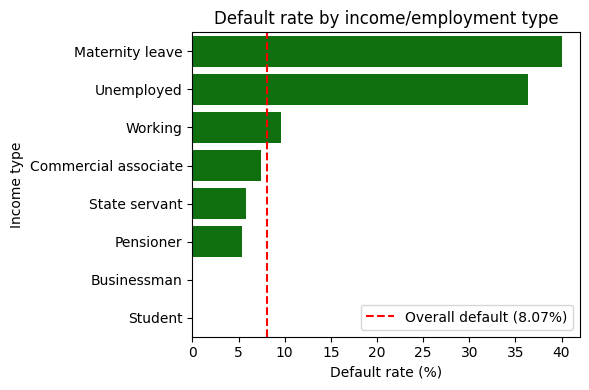

In [245]:
# 1) overall default rate in percent (from full data, not grouped)
overall_default_pct = app_full["TARGET"].mean() * 100

# 2) plot your bar chart and capture the axis
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=emp_grp,
    x="default_rate_pct",
    y="NAME_INCOME_TYPE",
    color="green",
    ax=ax
)

# 3) add vertical reference line at overall default rate
ax.axvline(
    x=overall_default_pct,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall default ({overall_default_pct:.2f}%)"
)

ax.set_xlabel("Default rate (%)")
ax.set_ylabel("Income type")
ax.set_title("Default rate by income/employment type")
ax.legend()
plt.tight_layout()
plt.show()


##### 4.	Do borrowers with more dependents (children/family size) default more?

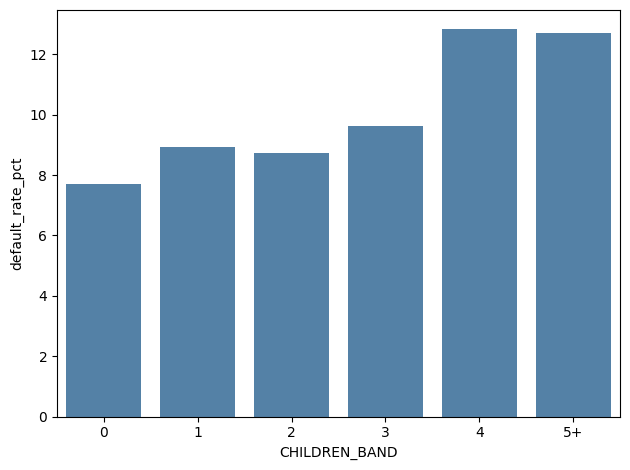

In [192]:
# 2. Create bands from capped columns
app_full["CHILDREN_BAND"] = app_full["CNT_CHILDREN"].replace({
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5+"
})

app_full["FAM_BAND"] = app_full["CNT_FAM_MEMBERS"].replace({
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7+"
})

# 3. Default vs children
child_grp = (app_full.groupby("CHILDREN_BAND")["TARGET"]
                        .mean()
                        .reset_index())
child_grp["default_rate_pct"] = child_grp["TARGET"] * 100
sns.barplot(data=child_grp, x="CHILDREN_BAND", y="default_rate_pct", color="steelblue")
plt.tight_layout() 
plt.show()



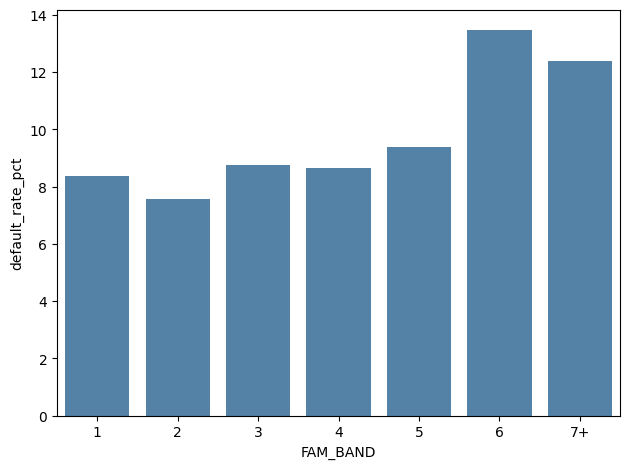

In [193]:

# 4. Default vs family size
fam_grp = (app_full.groupby("FAM_BAND")["TARGET"]
                      .mean()
                      .reset_index())
fam_grp["default_rate_pct"] = fam_grp["TARGET"] * 100
sns.barplot(data=fam_grp, x="FAM_BAND", y="default_rate_pct", color="steelblue")
plt.tight_layout() 
plt.show()

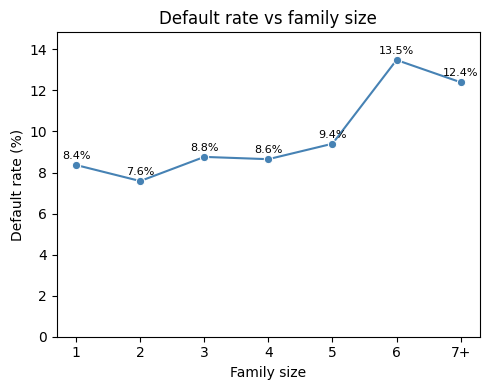

In [242]:
plt.figure(figsize=(5, 4))

# ensure proper order of bands
order = ["1", "2", "3", "4", "5", "6", "7+"]

sns.lineplot(
    data=fam_grp.sort_values("FAM_BAND", key=lambda s: s.map({b:i for i,b in enumerate(order)})),
    x="FAM_BAND",
    y="default_rate_pct",
    marker="o",
    color="steelblue"
)

plt.ylabel("Default rate (%)")
plt.xlabel("Family size")
plt.title("Default rate vs family size")
plt.ylim(0, fam_grp["default_rate_pct"].max() * 1.1)

for x, y in zip(fam_grp["FAM_BAND"], fam_grp["default_rate_pct"]):
    plt.text(x, y + 0.2, f"{y:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


##### 5.	What is the impact of education level on repayment?

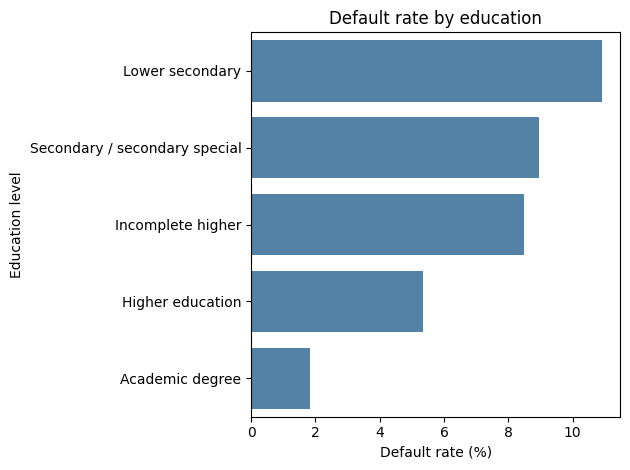

In [194]:
edu_grp = (app_full.groupby("NAME_EDUCATION_TYPE")["TARGET"]
                    .mean()
                    .reset_index()
                    .sort_values("TARGET", ascending=False))
edu_grp["default_rate_pct"] = edu_grp["TARGET"] * 100

sns.barplot(data=edu_grp, x="default_rate_pct", y="NAME_EDUCATION_TYPE", color="steelblue")
plt.xlabel("Default rate (%)"); plt.ylabel("Education level")
plt.title("Default rate by education"); plt.tight_layout(); plt.show()


### B)  Loan Structure Questions

##### 6.	How does loan amount relate to default risk?

4050000.0


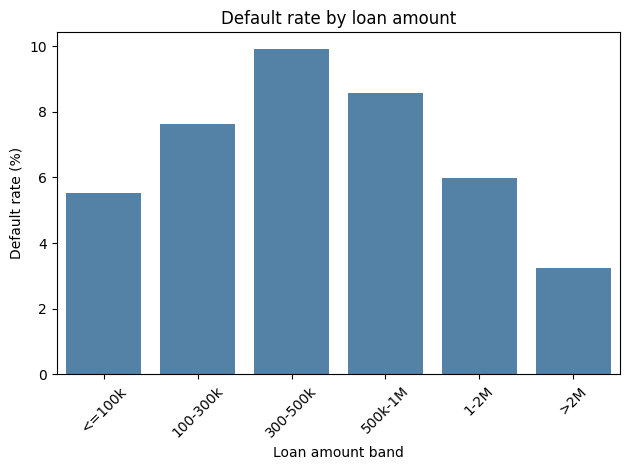

In [196]:
print(app_full["AMT_CREDIT"].max())
credit_bins   = [0, 100000, 300000, 500000, 1000000, 2000000, app_full["AMT_CREDIT"].max()]
credit_labels = ["<=100k", "100-300k", "300-500k", "500k-1M", "1-2M", ">2M"]

app_full["CREDIT_BAND"] = pd.cut(app_full["AMT_CREDIT"], credit_bins, labels=credit_labels, include_lowest=True)

cred_grp = (app_full.groupby("CREDIT_BAND", observed=True)["TARGET"]
                     .mean()
                     .reset_index())
cred_grp["default_rate_pct"] = cred_grp["TARGET"] * 100

sns.barplot(data=cred_grp, x="CREDIT_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("Loan amount band"); plt.ylabel("Default rate (%)"); plt.xticks(rotation=45)
plt.title("Default rate by loan amount"); plt.tight_layout(); plt.show()


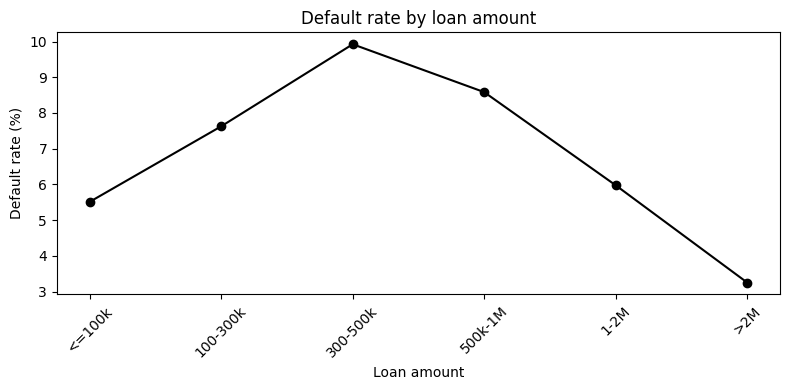

In [213]:
plt.figure(figsize=(8,4))

ax = plt.gca()

ax.plot(
    cred_grp["CREDIT_BAND"],
    cred_grp["default_rate_pct"],
    color="black",
    marker="o"
)

ax.set_xlabel("Loan amount")
ax.set_ylabel("Default rate (%)")
# ax2.set_ylabel("Default rate (%)")   # same scale for clarity
plt.title("Default rate by loan amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 7.	Do high EMIs (AMT_ANNUITY) lead to more defaults?

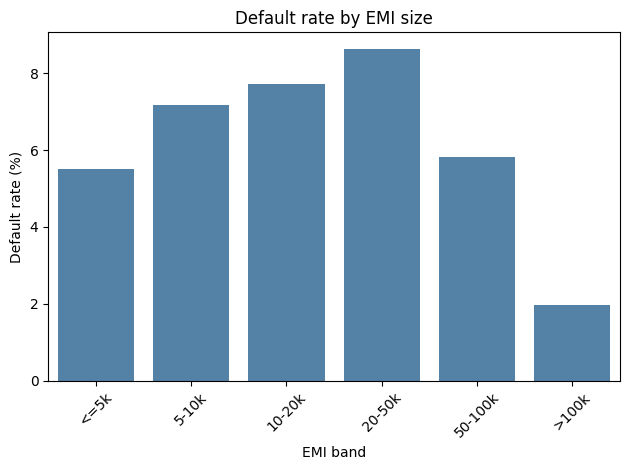

In [197]:
emi_bins   = [0, 5000, 10000, 20000, 50000, 100000, app_full["AMT_ANNUITY"].max()]
emi_labels = ["<=5k", "5-10k", "10-20k", "20-50k", "50-100k", ">100k"]

app_full["EMI_BAND"] = pd.cut(app_full["AMT_ANNUITY"], emi_bins, labels=emi_labels, include_lowest=True)

emi_grp = (app_full.groupby("EMI_BAND", observed=True)["TARGET"]
                     .mean()
                     .reset_index())
emi_grp["default_rate_pct"] = emi_grp["TARGET"] * 100

sns.barplot(data=emi_grp, x="EMI_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("EMI band"); plt.ylabel("Default rate (%)"); plt.xticks(rotation=45)
plt.title("Default rate by EMI size"); plt.tight_layout(); plt.show()


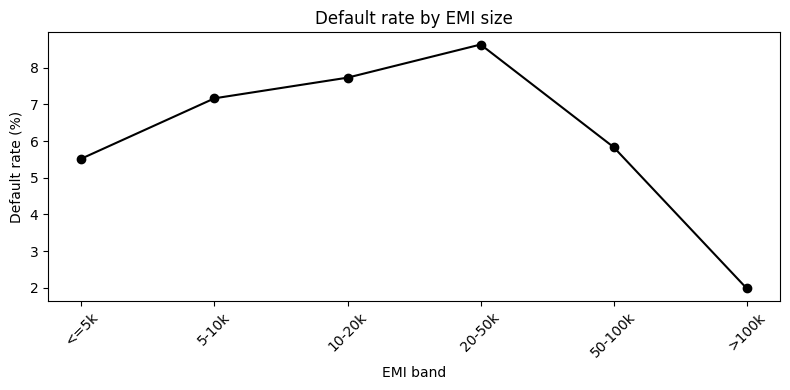

In [214]:
plt.figure(figsize=(8,4))

ax = plt.gca()

ax.plot(
    emi_grp["EMI_BAND"],
    emi_grp["default_rate_pct"],
    color="black",
    marker="o"
)

ax.set_xlabel("EMI band")
ax.set_ylabel("Default rate (%)")
plt.title("Default rate by EMI size")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 8.	Are certain contract types (cash vs revolving) riskier?

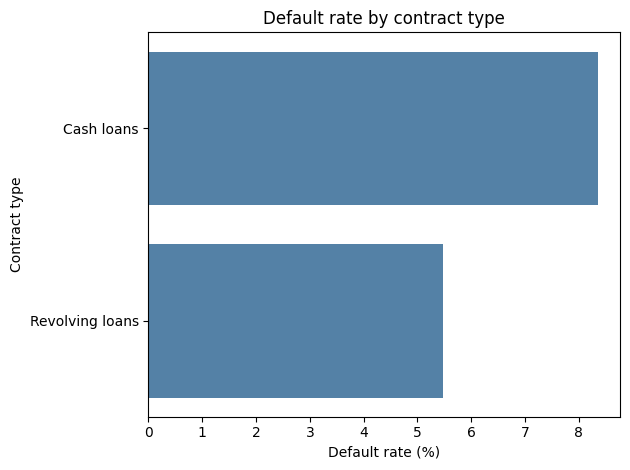

In [198]:
ct_grp = (app_full.groupby("NAME_CONTRACT_TYPE")["TARGET"]
                    .mean()
                    .reset_index()
                    .sort_values("TARGET", ascending=False))
ct_grp["default_rate_pct"] = ct_grp["TARGET"] * 100

sns.barplot(data=ct_grp, x="default_rate_pct", y="NAME_CONTRACT_TYPE", color="steelblue")
plt.xlabel("Default rate (%)"); plt.ylabel("Contract type")
plt.title("Default rate by contract type"); plt.tight_layout(); plt.show()

### C)  Credit Behavior Questions

##### 9.	Is there a link between credit bureau enquiries (recent loan shopping) and default?

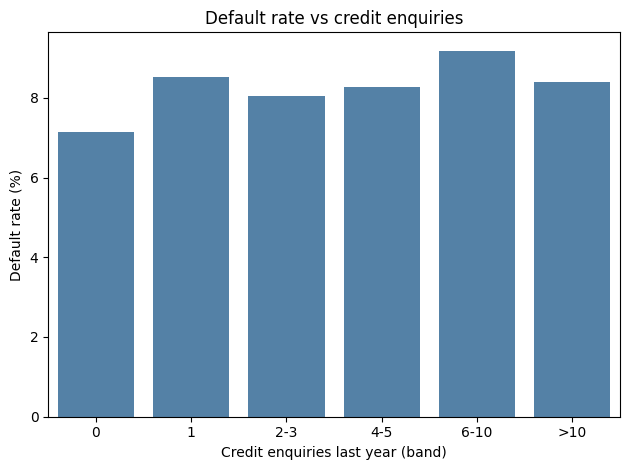

In [200]:
enq_bins   = [-0.1, 0, 1, 3, 5, 10, 100]
enq_labels = ["0", "1", "2-3", "4-5", "6-10", ">10"]

app_full["BUREAU_YEAR_BAND"] = pd.cut(app_full["AMT_REQ_CREDIT_BUREAU_YEAR"],
                                      bins=enq_bins, labels=enq_labels, include_lowest=True)

enq_grp = (app_full.groupby("BUREAU_YEAR_BAND", observed=True)["TARGET"]
                     .mean()
                     .reset_index())
enq_grp["default_rate_pct"] = enq_grp["TARGET"] * 100

sns.barplot(data=enq_grp, x="BUREAU_YEAR_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("Credit enquiries last year (band)"); plt.ylabel("Default rate (%)")
plt.title("Default rate vs credit enquiries"); plt.tight_layout(); plt.show()


##### 10.	Do clients with weak external scores (EXT_SOURCE) default more?

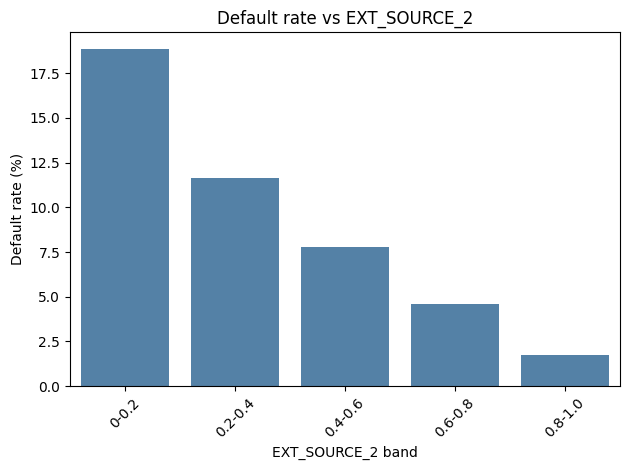

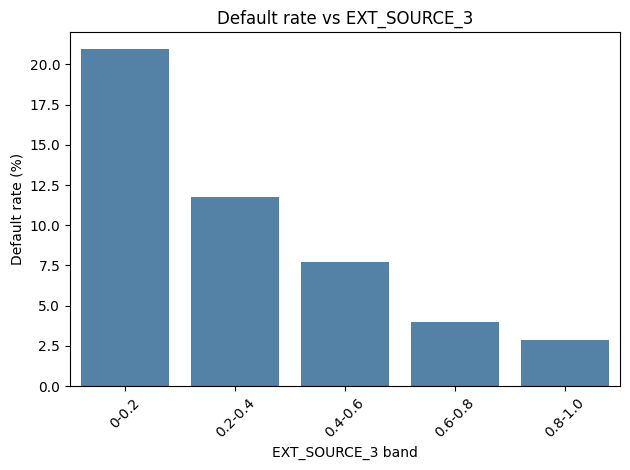

In [215]:
score_bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
score_labels = ["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

for col in ["EXT_SOURCE_2", "EXT_SOURCE_3"]:
    if col in app_full.columns:
        band_col = col + "_BAND"
        app_full[band_col] = pd.cut(app_full[col], bins=score_bins, labels=score_labels, include_lowest=True)

        sc_grp = (app_full.groupby(band_col, observed=True)["TARGET"]
                          .mean()
                          .reset_index())
        sc_grp["default_rate_pct"] = sc_grp["TARGET"] * 100

        sns.barplot(data=sc_grp, x=band_col, y="default_rate_pct", color="steelblue")
        plt.xlabel(col + " band"); plt.ylabel("Default rate (%)"); plt.xticks(rotation=45)
        plt.title(f"Default rate vs {col}"); plt.tight_layout(); plt.show()


In [218]:
print(app_full["EXT_SCORE_WEIGHTED"].corr(app_full["TARGET"]))

-0.21361752059098163


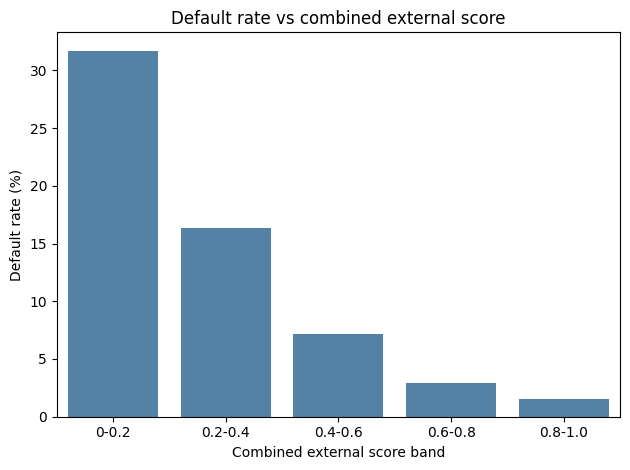

In [219]:
bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

app_full["EXT_WEIGHTED_BAND"] = pd.cut(
    app_full["EXT_SCORE_WEIGHTED"], bins=bins, labels=labels, include_lowest=True
)

grp = (app_full.groupby("EXT_WEIGHTED_BAND")["TARGET"]
                .mean()
                .reset_index())
grp["default_rate_pct"] = grp["TARGET"] * 100

sns.barplot(data=grp, x="EXT_WEIGHTED_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("Combined external score band")
plt.ylabel("Default rate (%)")
plt.title("Default rate vs combined external score")
plt.tight_layout()
plt.show()


##### 11.	Does owning a house or car reduce default risk?

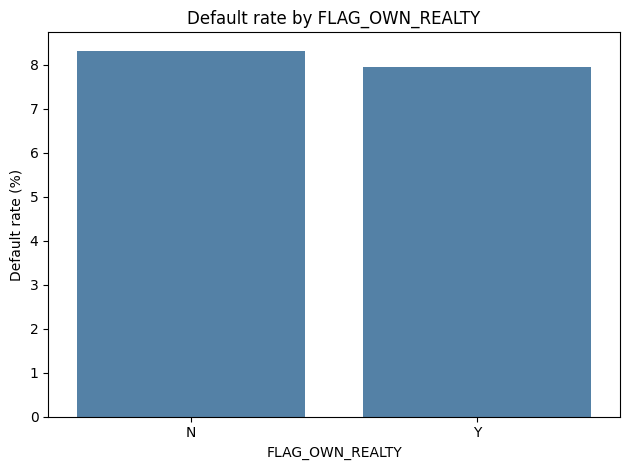

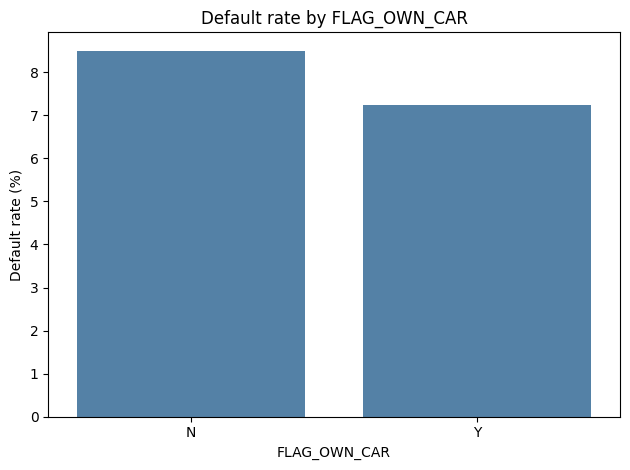

In [202]:
for col in ["FLAG_OWN_REALTY", "FLAG_OWN_CAR"]:
    if col in app_full.columns:
        own_grp = (app_full.groupby(col)["TARGET"]
                           .mean()
                           .reset_index())
        own_grp["default_rate_pct"] = own_grp["TARGET"] * 100

        sns.barplot(data=own_grp, x=col, y="default_rate_pct", color="steelblue")
        plt.xlabel(col); plt.ylabel("Default rate (%)")
        plt.title(f"Default rate by {col}"); plt.tight_layout(); plt.show()


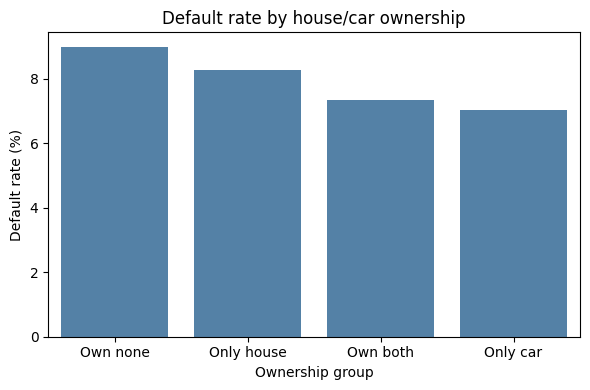

In [210]:
def own_category(row):
    own_house = (row["FLAG_OWN_REALTY"] == "Y")
    own_car   = (row["FLAG_OWN_CAR"] == "Y")
    if own_house and own_car:
        return "Own both"
    elif own_house and not own_car:
        return "Only house"
    elif not own_house and own_car:
        return "Only car"
    else:
        return "Own none"

app_full["OWNERSHIP_GROUP"] = app_full.apply(own_category, axis=1)

# compute default rate
own_grp = (app_full.groupby("OWNERSHIP_GROUP")["TARGET"]
                    .mean()
                    .sort_values(ascending=False)
                    .reset_index())
own_grp["default_rate_pct"] = own_grp["TARGET"] * 100

# plot
plt.figure(figsize=(6,4))
sns.barplot(data=own_grp, x="OWNERSHIP_GROUP", y="default_rate_pct", color="steelblue")
plt.ylabel("Default rate (%)")
plt.xlabel("Ownership group")
plt.title("Default rate by house/car ownership")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### D)  Past Loan Behavior (Previous Application)

##### 12.	Are customers with previously rejected loans more likely to default now?

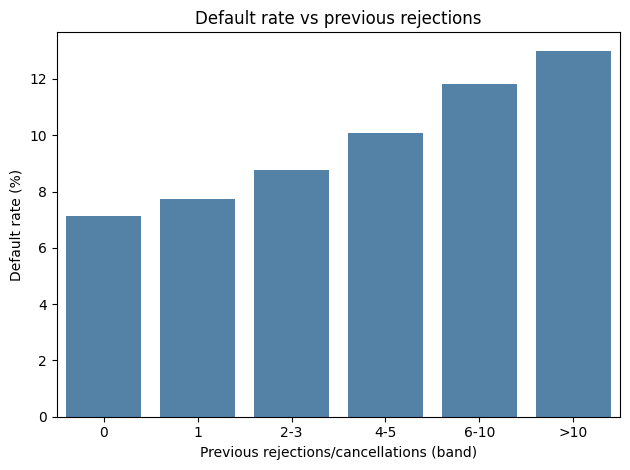

In [203]:
rej_bins   = [-0.1, 0, 1, 3, 5, 10, 100]
rej_labels = ["0", "1", "2-3", "4-5", "6-10", ">10"]

app_full["REJ_BAND"] = pd.cut(app_full["loan_rejected_or_cancelled_count"],
                              bins=rej_bins, labels=rej_labels, include_lowest=True)

rej_grp = (app_full.groupby("REJ_BAND", observed=True)["TARGET"]
                     .mean()
                     .reset_index())
rej_grp["default_rate_pct"] = rej_grp["TARGET"] * 100

sns.barplot(data=rej_grp, x="REJ_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("Previous rejections/cancellations (band)"); plt.ylabel("Default rate (%)")
plt.title("Default rate vs previous rejections"); plt.tight_layout(); plt.show()


##### 13.	Does requesting a very high AMT_APPLICATION vs AMT_CREDIT indicate risk?

In [204]:
prev = prev_df.copy()

# per-application ratio
prev["REQ_TO_CREDIT_RATIO"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]

# aggregate to customer level – choose what you want
ratio_agg = prev.groupby("SK_ID_CURR").agg(
    prev_mean_req_to_credit_ratio = ("REQ_TO_CREDIT_RATIO", "mean"),
    prev_max_req_to_credit_ratio  = ("REQ_TO_CREDIT_RATIO", "max")
)

# merge into app_full (which has TARGET)
app_full = app_full.merge(ratio_agg, on="SK_ID_CURR", how="left")


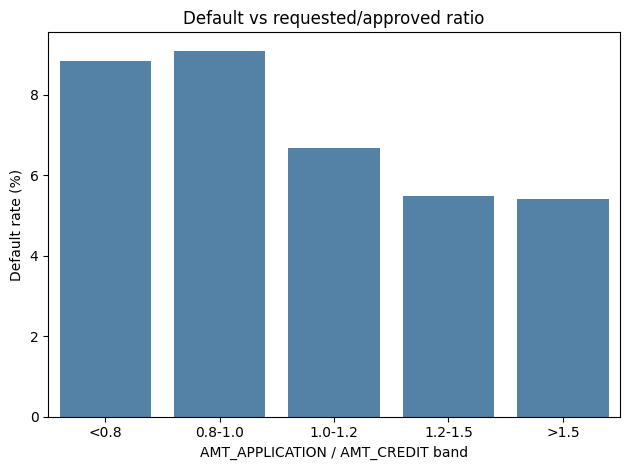

In [205]:
ratio_bins   = [0, 0.8, 1.0, 1.2, 1.5, 10]
ratio_labels = ["<0.8", "0.8-1.0", "1.0-1.2", "1.2-1.5", ">1.5"]

app_full["REQ_CRED_BAND"] = pd.cut(
    app_full["prev_mean_req_to_credit_ratio"],
    bins=ratio_bins, labels=ratio_labels, include_lowest=True
)

grp = (app_full.groupby("REQ_CRED_BAND", observed=True)["TARGET"]
               .mean()
               .reset_index())
grp["default_rate_pct"] = grp["TARGET"] * 100

sns.barplot(data=grp, x="REQ_CRED_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("AMT_APPLICATION / AMT_CREDIT band"); plt.ylabel("Default rate (%)")
plt.title("Default vs requested/approved ratio"); plt.tight_layout(); plt.show()


##### 14.	Does frequent loan application behaviour (multiple previous loans) predict default?

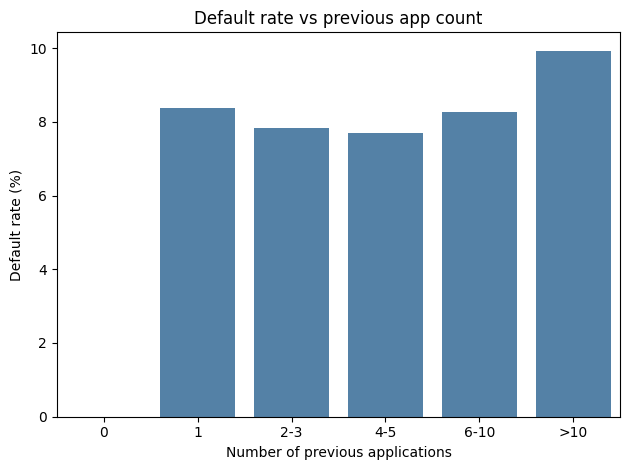

In [ ]:
apps_bins   = [-0.1, 0, 1, 3, 5, 10, 100]
apps_labels = ["1", "2-3", "4-5", "6-10", ">10"]

app_full["PREV_APP_COUNT_BAND"] = pd.cut(app_full["prev_application_count"],
                                         bins=apps_bins, labels=apps_labels, include_lowest=True)

apps_grp = (app_full.groupby("PREV_APP_COUNT_BAND", observed=True)["TARGET"]
                      .mean()
                      .reset_index())
apps_grp["default_rate_pct"] = apps_grp["TARGET"] * 100

sns.barplot(data=apps_grp, x="PREV_APP_COUNT_BAND", y="default_rate_pct", color="steelblue")
plt.xlabel("Number of previous applications"); plt.ylabel("Default rate (%)")
plt.title("Default rate vs previous app count"); plt.tight_layout(); plt.show()


In [231]:
app_full.to_csv("application_data_enhanced.csv", index=False)